## 1. Setup and Configuration

In [1]:
# Import required libraries
import time
import statistics
import mimerpy
from contextlib import contextmanager
from typing import List, Dict
import os
from dotenv import load_dotenv
import pandas as pd
import matplotlib.pyplot as plt

# Load environment variables
load_dotenv()

print("✓ Libraries imported successfully")

✓ Libraries imported successfully


In [2]:
# Database connection configuration
DB_CONFIG = {
    'dsn': os.getenv('DB_DSN'),
    'user': os.getenv('DB_USER'),
    'password': os.getenv('DB_PASSWORD')
}

print(f"Database: {DB_CONFIG['dsn']}")
print(f"User: {DB_CONFIG['user']}")

Database: imdb-db
User: admin


In [3]:
# The query to test
TEST_QUERY = """
SELECT MIN(mi.info) AS movie_budget, MIN(mi_idx.info) AS movie_votes, 
       MIN(n.name) AS writer, MIN(t.title) AS violent_liongate_movie 
FROM cast_info AS ci, company_name AS cn, info_type AS it1, info_type AS it2, 
     keyword AS k, movie_companies AS mc, movie_info AS mi, movie_info_idx AS mi_idx, 
     movie_keyword AS mk, name AS n, title AS t, char_name AS c, aka_name AS ak 
WHERE ci.note IN ('(writer)', '(head writer)', '(written by)', '(story)', '(story editor)') 
  AND cn.name LIKE 'Lionsgate%' 
  AND it1.info = 'genres' 
  AND it2.info = 'votes' 
  AND k.keyword IN ('murder', 'violence', 'blood', 'gore', 'death', 'female-nudity', 'hospital') 
  AND mi.info IN ('Horror', 'Thriller') 
  AND n.gender = 'm' 
  AND t.id = mi.movie_id 
  AND t.id = mi_idx.movie_id 
  AND t.id = ci.movie_id 
  AND t.id = mk.movie_id 
  AND t.id = mc.movie_id 
  AND ci.movie_id = mi.movie_id 
  AND ci.movie_id = mi_idx.movie_id 
  AND ci.movie_id = mk.movie_id 
  AND ci.movie_id = mc.movie_id 
  AND mi.movie_id = mi_idx.movie_id 
  AND mi.movie_id = mk.movie_id 
  AND mi.movie_id = mc.movie_id 
  AND mi_idx.movie_id = mk.movie_id 
  AND mi_idx.movie_id = mc.movie_id 
  AND mk.movie_id = mc.movie_id 
  AND n.id = ci.person_id 
  AND it1.id = mi.info_type_id 
  AND it2.id = mi_idx.info_type_id 
  AND k.id = mk.keyword_id 
  AND cn.id = mc.company_id 
  AND ak.name_pcode_nf = cn.name_pcode_nf 
  AND ak.name_pcode_cf = n.name_pcode_cf 
  AND c.name_pcode_nf = ak.name_pcode_nf
"""

print("✓ Query loaded")

✓ Query loaded


In [4]:
# Index definitions
CREATE_INDEXES = [
    "CREATE INDEX idx_cast_info_note ON cast_info(note)",
    "CREATE INDEX idx_company_name_name ON company_name(name)",
    "CREATE INDEX idx_info_type_info ON info_type(info)",
    "CREATE INDEX idx_keyword_keyword ON keyword(keyword)",
    "CREATE INDEX idx_movie_info_info ON movie_info(info)",
    "CREATE INDEX idx_name_gender ON name(gender)",
    "CREATE INDEX idx_aka_name_pcode_nf_cf ON aka_name(name_pcode_nf, name_pcode_cf)",
    "CREATE INDEX idx_company_name_pcode_nf ON company_name(name_pcode_nf)",
    "CREATE INDEX idx_name_pcode_cf ON name(name_pcode_cf)",
    "CREATE INDEX idx_char_name_pcode_nf ON char_name(name_pcode_nf)"
]

DROP_INDEXES = [
    "DROP INDEX idx_cast_info_note",
    "DROP INDEX idx_company_name_name",
    "DROP INDEX idx_info_type_info",
    "DROP INDEX idx_keyword_keyword",
    "DROP INDEX idx_movie_info_info",
    "DROP INDEX idx_name_gender",
    "DROP INDEX idx_aka_name_pcode_nf_cf",
    "DROP INDEX idx_company_name_pcode_nf",
    "DROP INDEX idx_name_pcode_cf",
    "DROP INDEX idx_char_name_pcode_nf"
]

print(f"✓ Configured {len(CREATE_INDEXES)} indexes")

✓ Configured 10 indexes


## 2. Helper Functions

In [5]:
@contextmanager
def get_connection(autocommit=False):
    """Context manager for database connection"""
    conn = mimerpy.connect(**DB_CONFIG, autocommit=autocommit)
    try:
        yield conn
    finally:
        conn.close()

def execute_query_with_timing(cursor, query: str) -> float:
    """Execute query and return execution time in seconds"""
    start_time = time.perf_counter()
    cursor.execute(query)
    result = cursor.fetchall()
    end_time = time.perf_counter()
    return end_time - start_time

def warmup_cache(cursor, query: str, iterations: int = 3):
    """Warm up database cache by running query multiple times"""
    print(f"Warming up cache ({iterations} iterations)...")
    for i in range(iterations):
        cursor.execute(query)
        cursor.fetchall()
        print(f"  Warmup {i+1}/{iterations} complete")

def run_benchmark(cursor, query: str, iterations: int = 5) -> List[float]:
    """Run benchmark and return list of execution times"""
    times = []
    print(f"\nRunning benchmark ({iterations} iterations)...")
    for i in range(iterations):
        exec_time = execute_query_with_timing(cursor, query)
        times.append(exec_time)
        print(f"  Run {i+1}/{iterations}: {exec_time:.4f} seconds")
    return times

def calculate_statistics(times: List[float]) -> Dict[str, float]:
    """Calculate statistics from timing results"""
    return {
        'mean': statistics.mean(times),
        'median': statistics.median(times),
        'stdev': statistics.stdev(times) if len(times) > 1 else 0,
        'min': min(times),
        'max': max(times)
    }

def create_indexes(cursor, conn):
    """Create all indexes"""
    print("\nCreating indexes...")
    for idx, sql in enumerate(CREATE_INDEXES, 1):
        try:
            cursor.execute(sql)
            conn.commit()  # Commit each DDL statement separately
            print(f"  [{idx}/{len(CREATE_INDEXES)}] Created: {sql.split()[2]}")
        except Exception as e:
            print(f"  [{idx}/{len(CREATE_INDEXES)}] Error: {e}")
            conn.rollback()

def drop_indexes(cursor, conn):
    """Drop all indexes"""
    print("\nDropping indexes...")
    for idx, sql in enumerate(DROP_INDEXES, 1):
        try:
            cursor.execute(sql)
            conn.commit()  # Commit each DDL statement separately
            print(f"  [{idx}/{len(DROP_INDEXES)}] Dropped: {sql.split()[2]}")
        except Exception as e:
            print(f"  [{idx}/{len(DROP_INDEXES)}] Error (may not exist): {e}")
            conn.rollback()

print("✓ Helper functions defined")

✓ Helper functions defined


## 3. Baseline Measurement (Before Indexes)

In [6]:
# Connect to database
conn = mimerpy.connect(**DB_CONFIG)
cursor = conn.cursor()

print("✓ Connected to database")

✓ Connected to database


In [7]:
# Warm up cache
warmup_cache(cursor, TEST_QUERY)

Warming up cache (3 iterations)...
  Warmup 1/3 complete
  Warmup 2/3 complete
  Warmup 3/3 complete


In [8]:
# Run baseline benchmark
baseline_times = run_benchmark(cursor, TEST_QUERY)
baseline_stats = calculate_statistics(baseline_times)

print("\n📊 Baseline Statistics:")
print(f"  Mean:   {baseline_stats['mean']:.4f} seconds")
print(f"  Median: {baseline_stats['median']:.4f} seconds")
print(f"  StdDev: {baseline_stats['stdev']:.4f} seconds")
print(f"  Min:    {baseline_stats['min']:.4f} seconds")
print(f"  Max:    {baseline_stats['max']:.4f} seconds")


Running benchmark (5 iterations)...
  Run 1/5: 223.2127 seconds
  Run 2/5: 220.1928 seconds
  Run 3/5: 222.9991 seconds
  Run 4/5: 223.7348 seconds
  Run 5/5: 223.7114 seconds

📊 Baseline Statistics:
  Mean:   222.7701 seconds
  Median: 223.2127 seconds
  StdDev: 1.4754 seconds
  Min:    220.1928 seconds
  Max:    223.7348 seconds


In [9]:
# Commit before DDL operations
conn.commit()
print("✓ Baseline measurements committed")

✓ Baseline measurements committed


## 4. Create Indexes

In [10]:
# Create all indexes
create_indexes(cursor, conn)
print("\n✓ Index creation complete")


Creating indexes...
  [1/10] Created: idx_cast_info_note
  [2/10] Created: idx_company_name_name
  [3/10] Created: idx_info_type_info
  [4/10] Created: idx_keyword_keyword
  [5/10] Created: idx_movie_info_info
  [6/10] Created: idx_name_gender
  [7/10] Created: idx_aka_name_pcode_nf_cf
  [8/10] Created: idx_company_name_pcode_nf
  [9/10] Created: idx_name_pcode_cf
  [10/10] Created: idx_char_name_pcode_nf

✓ Index creation complete


## 5. After Indexes

In [11]:
# Warm up cache again
warmup_cache(cursor, TEST_QUERY)

Warming up cache (3 iterations)...
  Warmup 1/3 complete
  Warmup 2/3 complete
  Warmup 3/3 complete


In [12]:
# Run post-index benchmark
postindex_times = run_benchmark(cursor, TEST_QUERY)
postindex_stats = calculate_statistics(postindex_times)

print("\n📊 Post-Index Statistics:")
print(f"  Mean:   {postindex_stats['mean']:.4f} seconds")
print(f"  Median: {postindex_stats['median']:.4f} seconds")
print(f"  StdDev: {postindex_stats['stdev']:.4f} seconds")
print(f"  Min:    {postindex_stats['min']:.4f} seconds")
print(f"  Max:    {postindex_stats['max']:.4f} seconds")


Running benchmark (5 iterations)...
  Run 1/5: 0.0021 seconds
  Run 2/5: 0.0003 seconds
  Run 3/5: 0.0001 seconds
  Run 4/5: 0.0001 seconds
  Run 5/5: 0.0001 seconds

📊 Post-Index Statistics:
  Mean:   0.0006 seconds
  Median: 0.0001 seconds
  StdDev: 0.0009 seconds
  Min:    0.0001 seconds
  Max:    0.0021 seconds


## 6. Results Comparison

In [13]:
# Calculate improvements
speedup = baseline_stats['mean'] / postindex_stats['mean']
improvement_pct = ((baseline_stats['mean'] - postindex_stats['mean']) / baseline_stats['mean']) * 100
time_saved = baseline_stats['mean'] - postindex_stats['mean']

print("="*80)
print("📈 COMPARISON RESULTS")
print("="*80)
print(f"\nBaseline (no indexes):  {baseline_stats['mean']:.4f} seconds")
print(f"Post-index (with idx):  {postindex_stats['mean']:.4f} seconds")
print(f"\n🚀 Speedup:             {speedup:.2f}x")
print(f"📊 Improvement:         {improvement_pct:.2f}%")
print(f"⏱️  Time saved:          {time_saved:.4f} seconds")

📈 COMPARISON RESULTS

Baseline (no indexes):  222.7701 seconds
Post-index (with idx):  0.0006 seconds

🚀 Speedup:             391385.62x
📊 Improvement:         100.00%
⏱️  Time saved:          222.7696 seconds


In [14]:
# Create comparison dataframe
comparison_df = pd.DataFrame({
    'Metric': ['Mean', 'Median', 'StdDev', 'Min', 'Max'],
    'Baseline (seconds)': [
        baseline_stats['mean'],
        baseline_stats['median'],
        baseline_stats['stdev'],
        baseline_stats['min'],
        baseline_stats['max']
    ],
    'Post-Index (seconds)': [
        postindex_stats['mean'],
        postindex_stats['median'],
        postindex_stats['stdev'],
        postindex_stats['min'],
        postindex_stats['max']
    ]
})

comparison_df['Improvement'] = (
    (comparison_df['Baseline (seconds)'] - comparison_df['Post-Index (seconds)']) / 
    comparison_df['Baseline (seconds)'] * 100
).round(2).astype(str) + '%'

display(comparison_df)

,Metric,Baseline (seconds),Post-Index (seconds),Improvement
0,Mean,222.770119,0.000569,100.0%
1,Median,223.212651,0.000142,100.0%
2,StdDev,1.475421,0.000858,99.94%
3,Min,220.192762,0.000135,100.0%
4,Max,223.734753,0.002096,100.0%


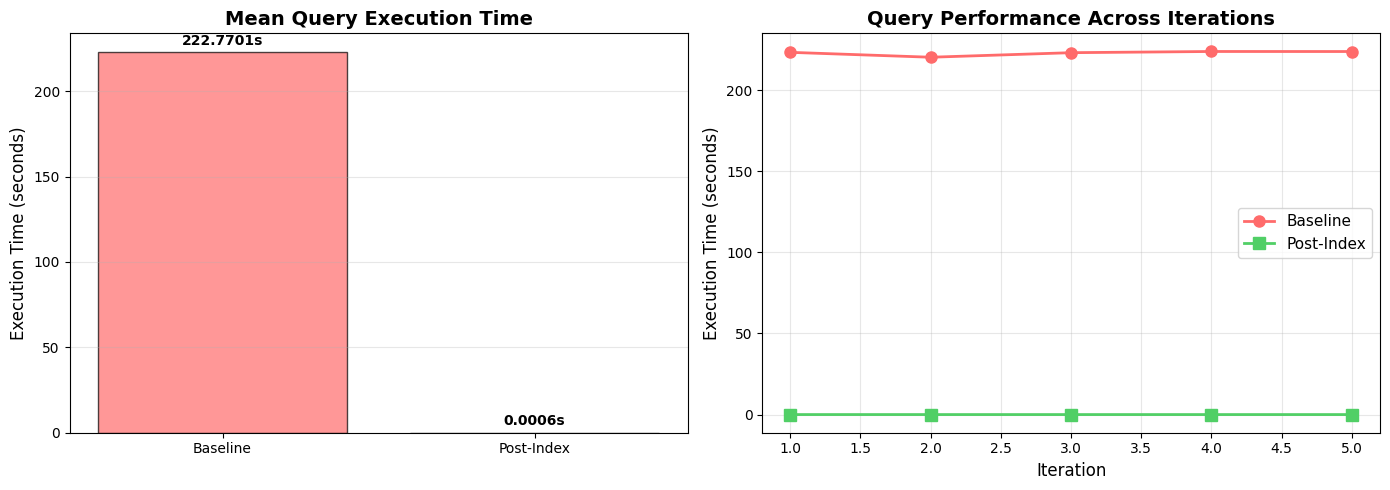


✓ Speedup: 391385.62x | Improvement: 100.00%


In [15]:
# Visualize results
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart comparison
x = ['Baseline', 'Post-Index']
means = [baseline_stats['mean'], postindex_stats['mean']]
colors = ['#ff6b6b', '#51cf66']

ax1.bar(x, means, color=colors, alpha=0.7, edgecolor='black')
ax1.set_ylabel('Execution Time (seconds)', fontsize=12)
ax1.set_title('Mean Query Execution Time', fontsize=14, fontweight='bold')
ax1.grid(axis='y', alpha=0.3)

# Add value labels
for i, v in enumerate(means):
    ax1.text(i, v + max(means)*0.02, f'{v:.4f}s', ha='center', fontweight='bold')

# Line chart of all iterations
ax2.plot(range(1, len(baseline_times)+1), baseline_times, 'o-', 
         label='Baseline', linewidth=2, markersize=8, color='#ff6b6b')
ax2.plot(range(1, len(postindex_times)+1), postindex_times, 's-', 
         label='Post-Index', linewidth=2, markersize=8, color='#51cf66')
ax2.set_xlabel('Iteration', fontsize=12)
ax2.set_ylabel('Execution Time (seconds)', fontsize=12)
ax2.set_title('Query Performance Across Iterations', fontsize=14, fontweight='bold')
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n✓ Speedup: {speedup:.2f}x | Improvement: {improvement_pct:.2f}%")

## 7. Cleanup

In [ ]:
# Uncomment to drop indexes
drop_indexes(cursor, conn)
print("\n✓ Indexes dropped")


Dropping indexes...
  [1/10] Error (may not exist): -14017 Mixing DDL and DML statements in a transaction is not allowed
  [2/10] Dropped: idx_company_name_name
  [3/10] Dropped: idx_info_type_info
  [4/10] Dropped: idx_keyword_keyword
  [5/10] Dropped: idx_movie_info_info
  [6/10] Dropped: idx_name_gender
  [7/10] Dropped: idx_aka_name_pcode_nf_cf
  [8/10] Dropped: idx_company_name_pcode_nf
  [9/10] Dropped: idx_name_pcode_cf
  [10/10] Dropped: idx_char_name_pcode_nf

✓ Indexes dropped


In [17]:
# Close connection
cursor.close()
conn.close()
print("✓ Database connection closed")

✓ Database connection closed
